In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as pat
import plotly
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from credit_utils.utils import *
colors = ['#FF5851', '#3d9dfc', '#d852fa', '#494a49', '#212121' , '#ffffff', '#727372', '#03fc39']


In [2]:
# from google.colab import drive
# drive.mount('/content/drive')

In [ ]:
df = load_creditcard_csv()
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


Cột Time: Đây là số giây (seconds) trôi qua tính từ giao dịch đầu tiên trong tập dữ liệu cho đến giao dịch hiện tại.
Các cột V1, V2,... V28: Đây là các đặc trưng đã qua biến đổi PCA.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
df.isna().sum()

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

Bộ dữ liệu này không bị thiếu giá trị (No Missing Values).

In [6]:
df_eda = df.copy()
df_eda["Hours"] = round(df['Time']/3600)
print('No Frauds', round(df_eda['Class'].value_counts()[0]/len(df_eda) * 100,2), '% of the dataset')
print('Frauds', round(df_eda['Class'].value_counts()[1]/len(df_eda) * 100,2), '% of the dataset')

No Frauds 99.83 % of the dataset
Frauds 0.17 % of the dataset


Biến Time sau khi chuyển đổi thành Hour có khả năng phân tách tốt cho các khung giờ đặc biệt, do đó đây là một đặc trưng quan trọng cho mô hình ML.

In [7]:
fig = go.Figure(data=[go.Pie(labels=["Non Fraud", "Fraud"], values=df_eda['Class'].value_counts(), pull=[0, 0.2])])
fig.update_layout(title_text="Fraud-Non Fraud (Class) Distribution", plot_bgcolor=colors[3], paper_bgcolor=colors[4], font_color=colors[5])
fig.update_traces(marker=dict(colors=[colors[1], colors[0]]))
fig.show()

Dữ liệu đang bị rất mất cân bằng

*   Lớp 0 (Giao dịch hợp lệ): 284,315 dòng (chiếm 99.83%)
*   Lớp 1 (Giao dịch gian lận): 492 dòng (chiếm 0.17%)



C:\Users\Dell\AppData\Local\Temp\ipykernel_31388\2163071226.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly_counts.reset_index(), x='Hours', y='Fraud_Rate', ax=ax3, palette='OrRd')


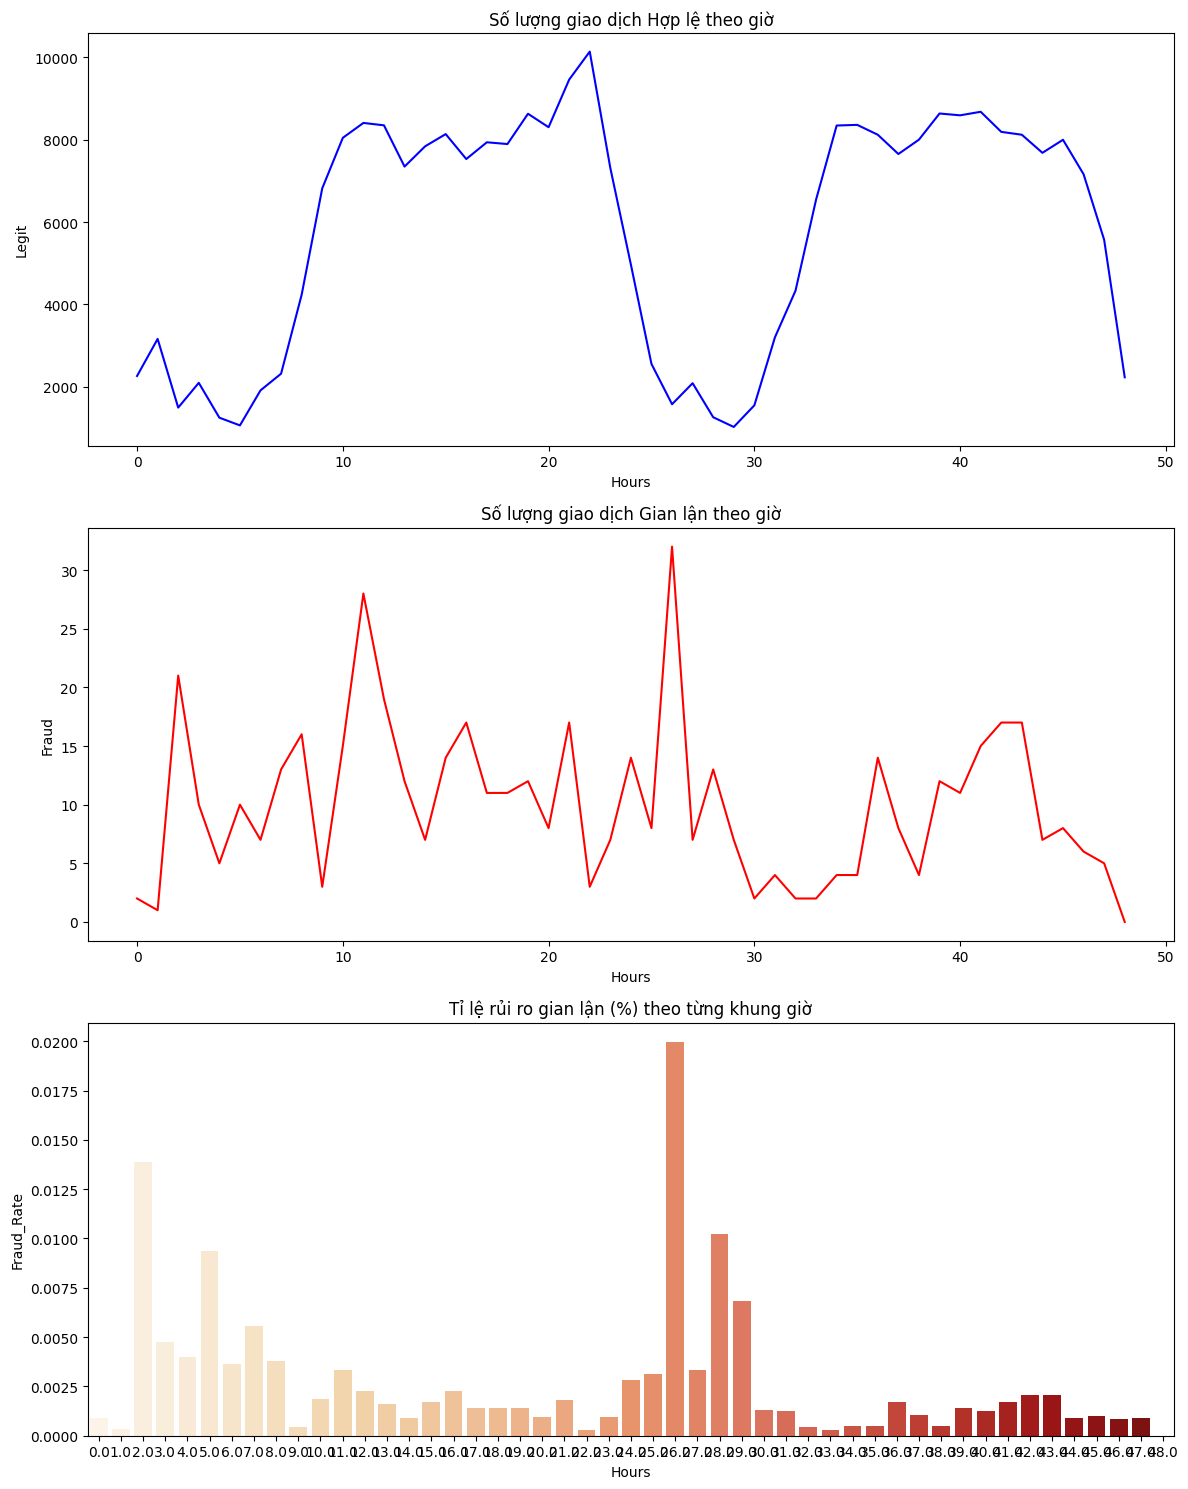

In [8]:
# 1. Chuẩn bị dữ liệu: Đếm số lượng theo từng giờ
hourly_counts = df_eda.groupby(['Hours', 'Class']).size().unstack(fill_value=0)
hourly_counts.columns = ['Legit', 'Fraud']

# 2. Tính tỉ lệ % gian lận trên tổng giao dịch (để thấy độ nguy hiểm)
hourly_counts['Fraud_Rate'] = hourly_counts['Fraud'] / (hourly_counts['Legit'] + hourly_counts['Fraud'])

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 15))

# Biểu đồ 1: Giao dịch bình thường
sns.lineplot(data=hourly_counts, x=hourly_counts.index, y='Legit', ax=ax1, color='blue')
ax1.set_title('Số lượng giao dịch Hợp lệ theo giờ')

# Biểu đồ 2: Giao dịch gian lận
sns.lineplot(data=hourly_counts, x=hourly_counts.index, y='Fraud', ax=ax2, color='red')
ax2.set_title('Số lượng giao dịch Gian lận theo giờ')

# Biểu đồ 3: Tỉ lệ rủi ro
sns.barplot(data=hourly_counts.reset_index(), x='Hours', y='Fraud_Rate', ax=ax3, palette='OrRd')
ax3.set_title('Tỉ lệ rủi ro gian lận (%) theo từng khung giờ')

plt.tight_layout()
plt.show()



1.   Biểu đồ 1 (Legit Transactions) : Nhịp sinh học của người dùng.Cho thấy thói quen chi tiêu thông thường.
2.   Hành vi của tội phạm (Fraud Transactions):Cho biết bọn tội phạm thường ra tay vào lúc nào.
3.   Chỉ số rủi ro (Fraud Rate/Ratio): cho biết khoảng thời gian nào mà gian lận dễ xảy ra nhất.


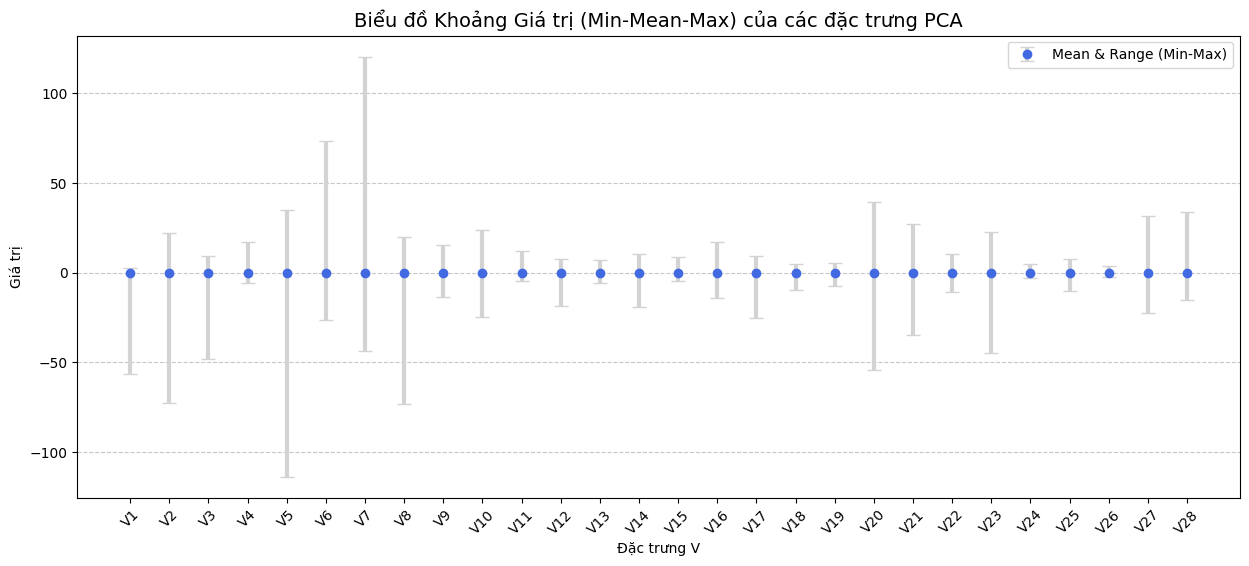

In [9]:
# 1. Lấy dữ liệu thống kê của các cột V (từ V1 đến V28)
v_stats = df.iloc[:, 1:-2].describe().T

# 2. Khởi tạo biểu đồ
plt.figure(figsize=(15, 6))

# 3. Vẽ đường thẳng nối Min - Max (Range) và điểm Mean
plt.errorbar(x=v_stats.index, y=v_stats['mean'],
             yerr=[v_stats['mean'] - v_stats['min'], v_stats['max'] - v_stats['mean']],
             fmt='o', color='royalblue', ecolor='lightgray',
             elinewidth=3, capsize=5, label='Mean & Range (Min-Max)')

plt.title("Biểu đồ Khoảng Giá trị (Min-Mean-Max) của các đặc trưng PCA", fontsize=14)
plt.xlabel("Đặc trưng V")
plt.ylabel("Giá trị")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plt.show()

Vì các đặc trưng từ $V_1$ đến $V_{28}$ đã có trung bình xấp xỉ 0 và thang đo tương đương nhau, chúng ta không cần thực hiện Scaling thêm cho các cột này. Thay vào đó, chúng ta chỉ cần tập trung xử lý (Scaling) cho cột Amount và Time để đưa chúng về cùng dải giá trị với các cột $V$, nhằm đảm bảo tính ổn định và công bằng cho mô hình phân loại.

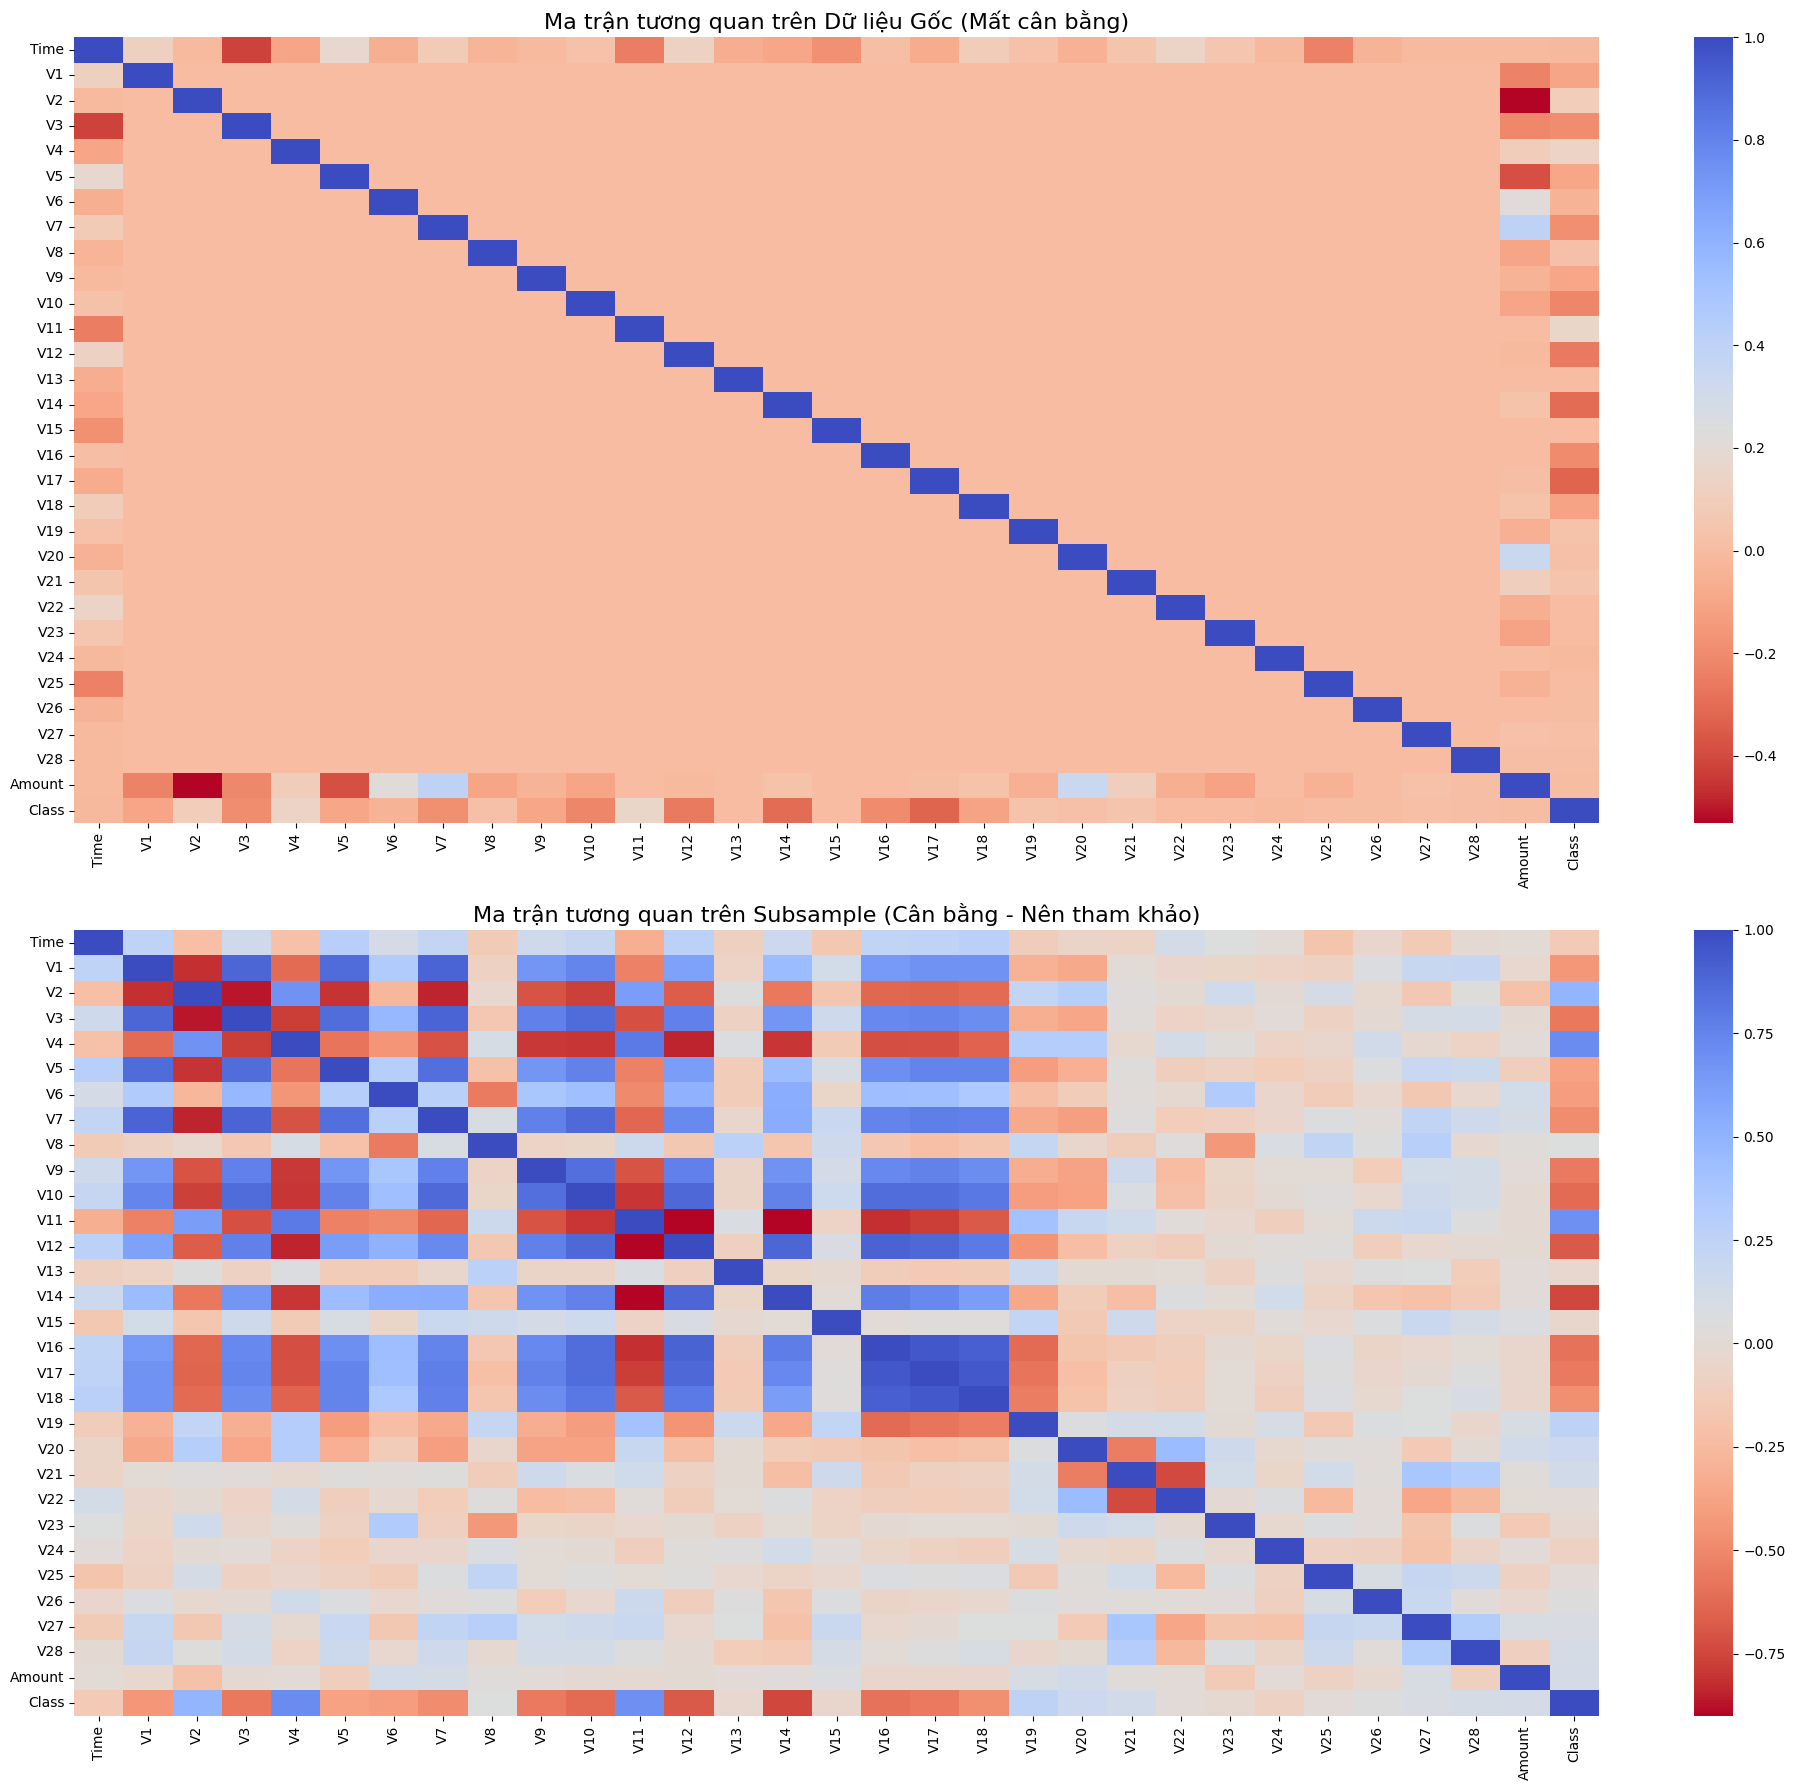

In [10]:
df = df.sample(frac=1)
fraud_df = df.loc[df['Class'] == 1]
non_fraud_df = df.loc[df['Class'] == 0][:492]
new_df = pd.concat([fraud_df, non_fraud_df])
new_df = new_df.sample(frac=1, random_state=42)
# 1. Thiết lập khung hình (2 hàng, 1 cột)
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 18))

# 2. Vẽ Heatmap cho Dữ liệu Gốc (Bị lệch)
# corr() tính toán hệ số tương quan Pearson giữa các cột
entire_corr = df.corr()
sns.heatmap(entire_corr, cmap='coolwarm_r', annot=False, ax=ax1)
ax1.set_title("Ma trận tương quan trên Dữ liệu Gốc (Mất cân bằng)", fontsize=16)

# 3. Vẽ Heatmap cho Dữ liệu Subsample (Đã cân bằng)
# Giả sử new_df là tập dữ liệu đã qua Undersampling (tỉ lệ 50/50)
sub_corr = new_df.corr()
sns.heatmap(sub_corr, cmap='coolwarm_r', annot=False, ax=ax2)
ax2.set_title("Ma trận tương quan trên Subsample (Cân bằng - Nên tham khảo)", fontsize=16)

plt.tight_layout()
plt.show()



*   Các biến nổi bật: $V17, V14, V12, V10$: Có mối quan hệ tỉ lệ nghịch với khả năng gian lận.Khi giá trị của các biến này càng giảm (càng âm), thì xác suất giao dịch đó là gian lận càng tăng.
*   Các biến nổi bật: $V2, V4, V11, V19$: Có mối quan hệ tỉ lệ thuận với khả năng gian lận. Khi giá trị của các biến này càng tăng (càng cao), thì xác suất giao dịch đó là gian lận càng tăng.



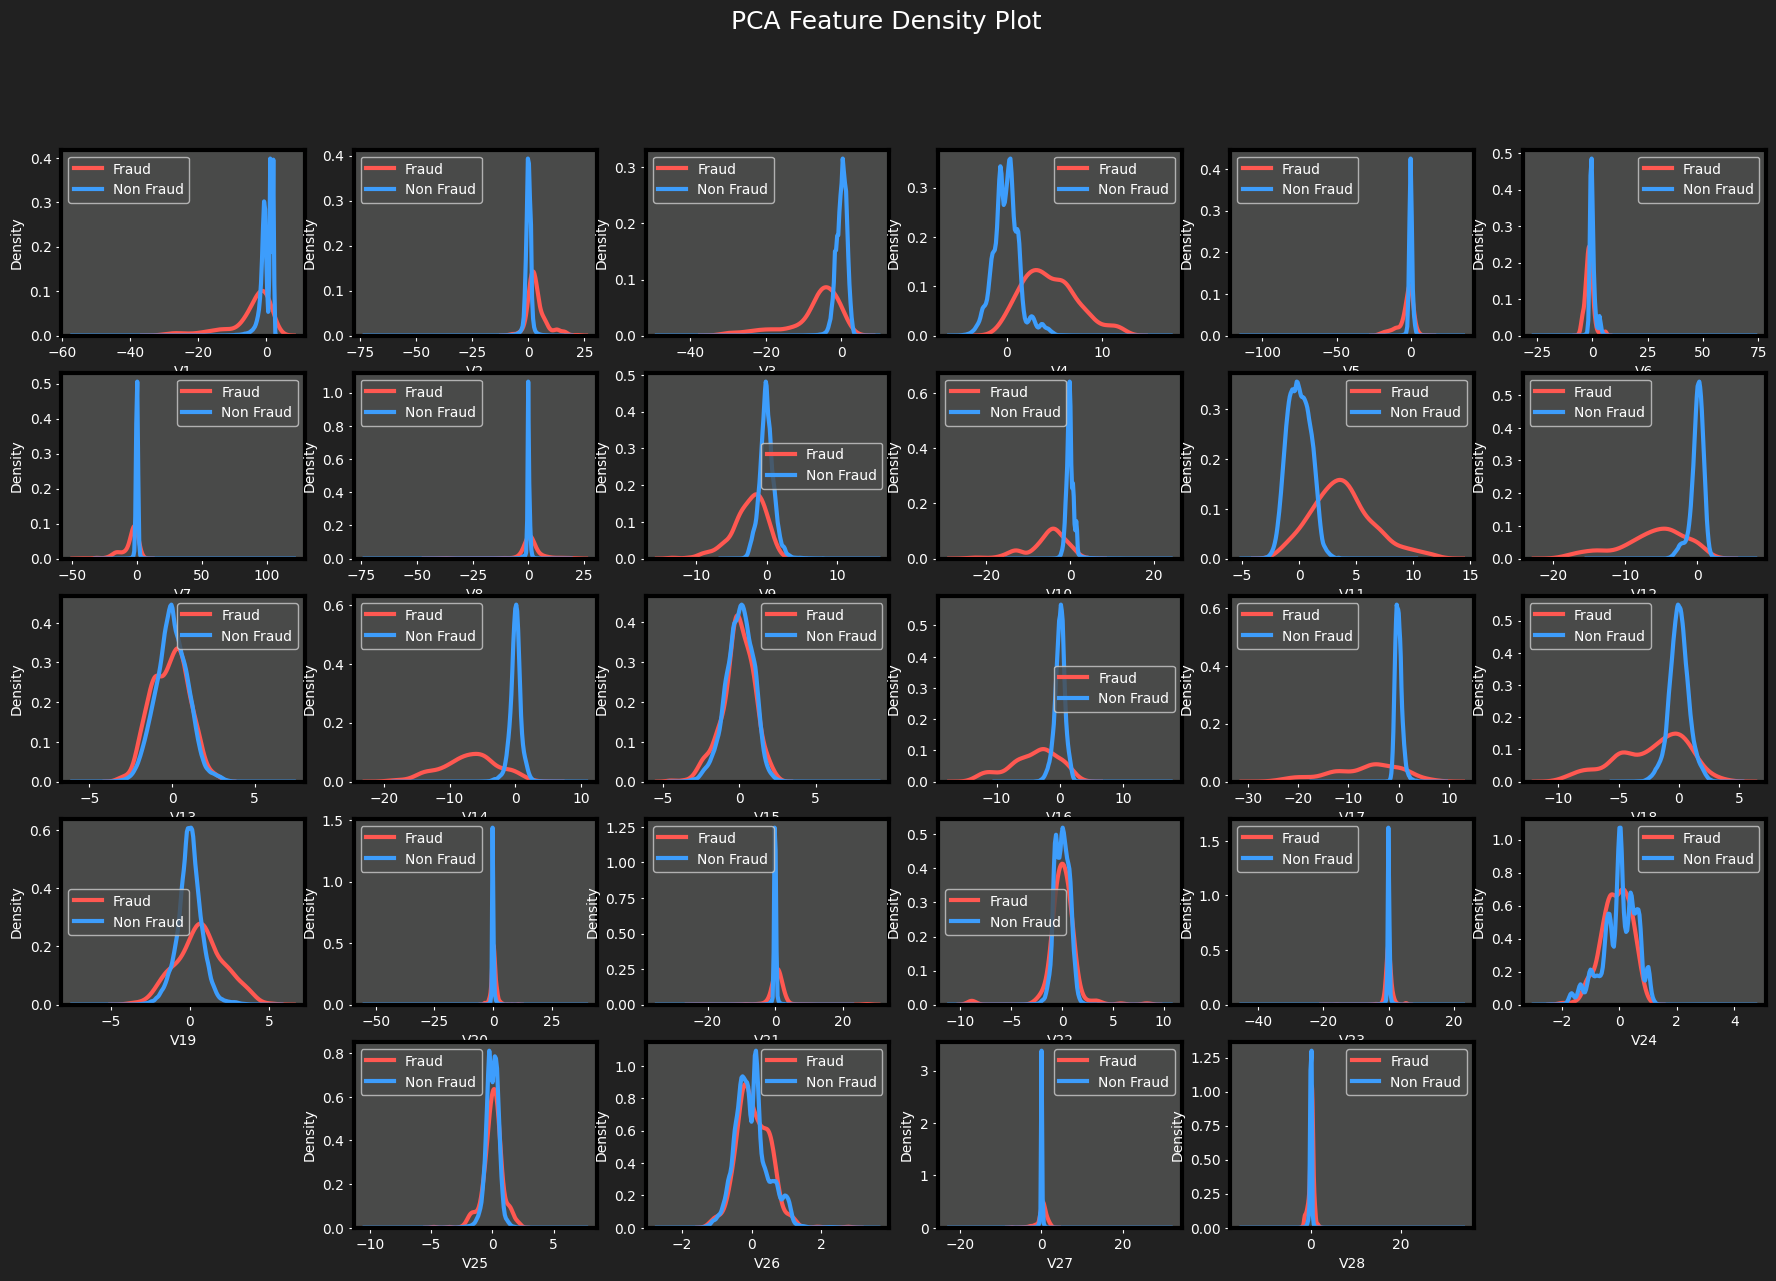

In [11]:
fig = plt.figure(figsize=(22, 14))
fig.tight_layout(pad=3.0)

# Plot parameters
plt.rcParams["figure.autolayout"] = True
plt.rcParams["axes.facecolor"] = colors[3]
plt.rcParams["axes.linewidth"] = 3
plt.rcParams["xtick.color"] = colors[5]
plt.rcParams["ytick.color"] = colors[5]
plt.rcParams["axes.labelcolor"] = colors[5]
plt.rcParams["axes.labelcolor"] = colors[5]
plt.rcParams["text.color"] = colors[5]
plt.rcParams["figure.titlesize"] = 18
fig.patch.set_facecolor(colors[4])
plt.suptitle("PCA Feature Density Plot")

# Subplots
for idx, i in enumerate(df_eda.columns[1:-3]):
    # for centering last subplots
    if idx+1 >=25:
        idx += 1

    plt.subplot(5, 6, idx+1)
    sns.kdeplot(x=df_eda[df_eda['Class'] == 1][i], linewidth=3, color=colors[0])
    sns.kdeplot(x=df_eda[df_eda['Class'] == 0][i], linewidth=3, color=colors[1])

    plt.legend(labels=['Fraud', 'Non Fraud'])



1.   Hai đường cong tách rời nhau (Separated)
Đỉnh của đường Fraud nằm lệch hẳn so với đỉnh của đường Non-Fraud (ví dụ ở các biến $V14, V12, V17$) Biến này rất mạnh để dự đoán
2.   Hai đường cong trùng khít lên nhau (Overlapped)
Nếu hai đường gần như nhập làm một (ví dụ thường thấy ở $V13, V15, V22, V26$), thì biến đó rất "Yếu".
3.   Hình dáng đường cong (Skewness)
Nếu đường cong của Fraud nhọn và cao, trong khi Non-Fraud bè ra, điều đó cho thấy hành vi của tội phạm rất tập trung ở một dải giá trị nhất định, khác hẳn với sự đa dạng của người dùng bình thường.




In [12]:
features = df_eda.iloc[:, 1:-2]
z_scores_array = np.abs(stats.zscore(features))
outlier_mask = pd.DataFrame(z_scores_array > 3, columns=features.columns, index=features.index)
ol_df2 = outlier_mask.groupby(df_eda['Class']).sum().T
ol_df2.columns = ['Class 0', 'Class 1']

# 1. Tính toán tỉ lệ Outliers trên mỗi lớp (Ratio = Số Outliers / Tổng số mẫu của lớp đó)
# Giúp so sánh công bằng vì số lượng Class 0 lớn hơn Class 1 rất nhiều
count_0 = df_eda['Class'].value_counts()[0]
count_1 = df_eda['Class'].value_counts()[1]

ol_df2['Ratio 0'] = ol_df2['Class 0'] / count_0
ol_df2['Ratio 1'] = ol_df2['Class 1'] / count_1

# 2. Tính phần trăm đóng góp của mỗi lớp vào tổng "độ nhiễu" (Outlier Density)
total_ratio = ol_df2['Ratio 0'] + ol_df2['Ratio 1']
ol_df2['Non-Fraud (%)'] = (ol_df2['Ratio 0'] / total_ratio) * 100
ol_df2['Fraud (%)'] = (ol_df2['Ratio 1'] / total_ratio) * 100

# 3. Sắp xếp theo % Fraud để thấy đặc trưng nào "gian lận nhất" ở trên cùng
ol_df2 = ol_df2.sort_values(by='Fraud (%)', ascending=True)

# 4. Vẽ biểu đồ bằng Plotly Express (Cực kỳ đơn giản)
fig = px.bar(ol_df2,
             y=ol_df2.index,
             x=['Non-Fraud (%)', 'Fraud (%)'],
             orientation='h',
             title="Tỉ lệ phân bổ Outliers giữa Gian lận và Hợp lệ",
             color_discrete_map={'Non-Fraud (%)': colors[1], 'Fraud (%)': colors[0]},
             labels={'value': 'Phần trăm (%)', 'index': 'Đặc trưng PCA'},
             height=800)

fig.update_layout(barmode='stack', title_x=0.5, template='plotly_dark')
fig.show()



Gian lận hầu như luôn đi kèm với sự bất thường (Outlier). Một giao dịch hợp lệ hiếm khi là Outlier, nhưng một giao dịch gian lận thì cực kỳ dễ trở thành Outlier.




**PREPROCESSING**

In [13]:
df = load_creditcard_csv()
X_train, X_val, X_test, y_train, y_val, y_test = preprocess_credit_card_data(df)
# SMOTE chỉ áp dung cho tập train để tránh rò rỉ thông tin từ tập test
X_train_sm, y_train_sm = apply_smote(X_train, y_train)

1. Tách Features (X) và Target (y)...
2. Chia tập Train+Val / Test (80/20) với Stratify...
3. Chia tập Train / Val (70/10) với Stratify...
4. Áp dụng RobustScaler cho Time và Amount (fit trên train)...

Kích thước các tập:
  Train : (199364, 30) | Fraud rate: 0.173%
  Val   : (28481, 30)   | Fraud rate: 0.172%
  Test  : (56962, 30)  | Fraud rate: 0.172%
Sau SMOTE — Train: (398038, 30) | Fraud rate: 50.0%


Trong quá trình EDA, dữ liệu thẻ tín dụng: Các giao dịch gian lận hầu hết tập trung ở vùng ngoại lai (Outliers). Nghĩa là, Outliers ở đây chính là "tín hiệu" (Signal) chứ không phải là nhiễu (Noise). Điều này khiến chúng ta chọn phương pháp chuẩn hóa RobustScaler




In [14]:
print("--- KÍCH THƯỚC DỮ LIỆU ---")
print(f"X_train_smote (sau SMOTE) : {X_train_sm.shape}")
print(f"X_val               : {X_val.shape}")
print(f"X_test              : {X_test.shape}")

print("\n--- TỈ LỆ LỚP TRÊN TẬP TRAIN (Sau SMOTE) ---")
print(pd.Series(y_train_sm).value_counts(normalize=True).rename({0: 'Legit', 1: 'Fraud'}) * 100)

print("\n--- TỈ LỆ LỚP TRÊN TẬP TEST (Giữ nguyên gốc) ---")
print(pd.Series(y_test).value_counts(normalize=True) * 100)

feature_names = [col for col in df.columns if col not in ['Class', 'Time', 'Amount']] + ['scaled_amount', 'scaled_time']
X_train_sm_df = pd.DataFrame(X_train_sm, columns=feature_names)

print("\n--- THỐNG KÊ CỦA AMOUNT VÀ TIME SAU KHI SCALE ---")
print(X_train_sm_df[['scaled_amount', 'scaled_time']].describe().T[['mean', 'min', 'max']])


--- KÍCH THƯỚC DỮ LIỆU ---
X_train_smote (sau SMOTE) : (398038, 30)
X_val               : (28481, 30)
X_test              : (56962, 30)

--- TỈ LỆ LỚP TRÊN TẬP TRAIN (Sau SMOTE) ---
Legit    50.0
Fraud    50.0
Name: proportion, dtype: float64

--- TỈ LỆ LỚP TRÊN TẬP TEST (Giữ nguyên gốc) ---
0    99.827955
1     0.172045
Name: proportion, dtype: float64

--- THỐNG KÊ CỦA AMOUNT VÀ TIME SAU KHI SCALE ---
                   mean       min         max
scaled_amount  1.081089 -0.305938  273.043109
scaled_time    0.039289 -0.996888    1.032140
